In [1]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar2.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')


In [2]:
ds_era5 = xr.open_dataset('data/era5_sea_ice_to_libradtran.nc')
ds_era5['z'] = ds_era5['theta'] * 0 # we still need z coordinates though we don't use them

/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
ds_era5

<xarray.Dataset> Size: 133kB
Dimensions:         (season: 4, valid_time: 8, sea_ice_cover: 10,
                     pressure_level: 13)
Coordinates:
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
  * season          (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
  * valid_time      (valid_time) datetime64[ns] 64B 1982-07-02T12:00:00 ... 2...
  * sea_ice_cover   (sea_ice_cover) float64 80B 0.05 0.15 0.25 ... 0.85 0.95
Data variables:
    t               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    q               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    theta           (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...
    z               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB ...

In [4]:
import pandas as pd
import pvlib

def calculate_solar_zenith_angle(time, latitude, longitude):
    solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    return solpos['zenith']

In [5]:
list_of_ds_cre_total = []
list_of_ds_cre_solar = []
list_of_ds_cre_thermal = []


for sic in ds_era5.sea_ice_cover.values:
    sic_cover = sic

    ds_era5_sel = ds_era5.sel(season='MAM', sea_ice_cover=sic_cover)
    ds_era5_sel

    ALBEDO_SEA_ICE = 0.9
    ALBEDO_OCEAN = 0.05
    albedo_sw = (ALBEDO_SEA_ICE * sic_cover + ALBEDO_OCEAN * (1 - sic_cover))
    albedos_sw = np.array([albedo_sw])
    albedos_lw = albedos_sw.copy() * 0.5

    cbh   = [0.3]        # km
    cth   = [1.0]        # km

    lwps = np.array([10, 15, 20, 30, 50, 100, 200, 400])
    lwcs = lwps / 700
    reffs = [15]                    # µm

    surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
    cbh = [0.3] * len(lwcs)
    cth = [1] * len(lwcs)
    # add a low-level cloud with varying LWC
    times = pd.date_range("2024-03-01 12:00", periods=12, freq="7d")
    lats = np.linspace(80, 60, 12)
    lon = [0] * len(times)
    altitudes = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 10, 100]
    #szas = np.arange(30, 90, 5)

    ds = xr.Dataset(
        coords={
            "time": times, 
            "latitude": (("time",), lats), 
            "longitude": (("time",), lon),
            "altitude": (("altitude",), altitudes)
        },
        data_vars={
            "lwc": (("lwc",), lwcs),
            "reff": (("reff",), reffs),
            "cth": (("lwc",), cth),
            "cbh": (("lwc",), cbh),
            "surface_temperature": (("albedo",), surface_temperatures),
            "albedo_sw": (("albedo",), albedos_sw),
            "albedo_lw": (("albedo",), albedos_lw),
        }
    )

    ds_sim_no_cloud_solar = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_solar.yaml',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_sw',
        #surface_type_var='surface_type',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, )

    ds_sim_no_cloud_thermal = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_thermal.yaml',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_lw',
        #surface_type_var='surface_type',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, )

    ds_sim_cloudy_solar = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_solar.yaml',
        cloud_wc_var='lwc',
        cloud_reff_var='reff',
        cloud_top_var='cth',
        cloud_bottom_var='cbh',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_sw',
        #surface_type_var='surface_type',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, )

    ds_sim_cloudy_thermal = ds.pyradtran.run(
        config_path='config/arctic_cloud_experiment_thermal.yaml',
        cloud_wc_var='lwc',
        cloud_reff_var='reff',
        cloud_top_var='cth',
        cloud_bottom_var='cbh',
        surface_temperature_var='surface_temperature',
        albedo_var='albedo_lw',
        #surface_type_var='surface_type',
        save_to_file=True, 
        return_dataset=True,
        era5_atmosphere=ds_era5_sel, )

    sza = calculate_solar_zenith_angle(ds.time.values, ds.latitude.values, ds.longitude.values)


    ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
    ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
    ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
    ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
    ds_cre_total = ds_cre_solar + ds_cre_thermal
    ds_cre_total = ds_cre_total.squeeze()
    ds_cre_total['sza'] = ('time', sza)
    ds_cre_total = ds_cre_total.swap_dims({'time': 'sza'})


    list_of_ds_cre_total.append(ds_cre_total)
    list_of_ds_cre_solar.append(ds_cre_solar)
    list_of_ds_cre_thermal.append(ds_cre_thermal)

Running simulations: 100%|██████████| 96/96 [00:36<00:00,  2.66sim/s, Success=95, Total=96]
2025-12-14 01:52:09,612 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 96/96 [00:08<00:00, 11.88sim/s, Success=93, Total=96]
2025-12-14 01:52:17,805 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 96/96 [00:45<00:00,  2.13sim/s, Success=96, Total=96]
2025-12-14 01:53:03,041 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 96/96 [00:10<00:00,  9.58sim/s, Success=96, Total=96]
2025-12-14 01:53:13,178 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
Running simulations: 100%|██████████| 96/96 [00:36<00:00,  2.66sim/s, Success=95, Total=96]
2025-12-14 01:53:49,349 - pyradtran.config -

In [6]:
ds_cre_total_all = xr.concat(list_of_ds_cre_total, dim='albedo_sw')
ds_cre_solar_all = xr.concat(list_of_ds_cre_solar, dim='albedo_sw')
ds_cre_thermal_all = xr.concat(list_of_ds_cre_thermal, dim='albedo_sw')

albedos = ALBEDO_OCEAN * (1 - ds_era5.sea_ice_cover) + ALBEDO_SEA_ICE * ds_era5.sea_ice_cover

ds_cre_total_all['albedo_sw'] = ('albedo_sw', albedos.values)
ds_cre_solar_all['albedo_sw'] = ('albedo_sw', albedos.values)
ds_cre_thermal_all['albedo_sw'] = ('albedo_sw', albedos.values)


Text(0, 0.5, 'Surface albedo ')

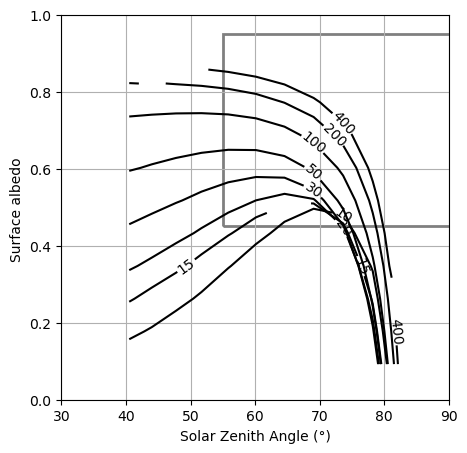

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

colors = plt.cm.inferno(np.linspace(0, 1, len(ds_cre_total.lwc)))

for i, lwc in enumerate(ds_cre_total.lwc.values):
        
    cs = ds_cre_total_all.isel(altitude=0).sel(lwc=lwc).enet.plot.contour(x='sza', colors='k', levels=[0])
    # add lwc to complete the label 
    cs.clabel(fmt=f'{lwps[i]}', colors='k')

# show SHEBA region
from matplotlib.patches import Rectangle

ax.add_patch(Rectangle((55, .45), 50, .5, alpha=0.5, edgecolor='k', linewidth=2, fill=False))

ax.set_xlim(30, 90)
ax.set_ylim(0, 1)
ax.set_title('')
ax.grid()
ax.set_xlabel('Solar Zenith Angle (°)')
ax.set_ylabel('Surface albedo ')